# 09 - Feature and Error Analysis

Mục tiêu: Phân tích các đặc trưng quan trọng (Feature Importance) và phân tích các trường hợp dự đoán sai (Error Analysis) của 2 mô hình tốt nhất trên 2 tập dữ liệu (ISOT và WELFake).

In [9]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports' / '09_feature_error_analysis'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style('whitegrid')

## 1. Feature Analysis: Tầm quan trọng của từ khóa
Tự động đọc file JSON để lấy mô hình tốt nhất và vẽ biểu đồ tương ứng (hỗ trợ cả `.coef_` và `.feature_importances_`).

In [10]:
# Hàm hỗ trợ vẽ biểu đồ tự động tương thích với cả Linear Model và Tree-based Model
def plot_top_features(model, feature_names, top_n=20, title="Top Features"):
    if hasattr(model, 'coef_'):
        # Linear Model (SVM, Logistic Regression)
        coef = model.coef_[0]
        top_positive_indices = np.argsort(coef)[-top_n:]
        top_negative_indices = np.argsort(coef)[:top_n]
        
        top_indices = np.concatenate([top_negative_indices, top_positive_indices])
        top_features = feature_names[top_indices]
        top_coefs = coef[top_indices]
        
        colors = ['green' if c < 0 else 'red' for c in top_coefs]
        
        plt.figure(figsize=(10, 10))
        plt.barh(np.arange(len(top_features)), top_coefs, color=colors)
        plt.yticks(np.arange(len(top_features)), top_features)
        plt.xlabel('Coefficient Value')
        plt.title(title)
        
        import matplotlib.patches as mpatches
        real_patch = mpatches.Patch(color='green', label='REAL (0)')
        fake_patch = mpatches.Patch(color='red', label='FAKE (1)')
        plt.legend(handles=[real_patch, fake_patch], loc='lower right')
        
    elif hasattr(model, 'feature_importances_'):
        # Tree-based Model (Random Forest)
        importances = model.feature_importances_
        top_indices = np.argsort(importances)[-top_n:]
        top_features = feature_names[top_indices]
        top_importances = importances[top_indices]
        
        plt.figure(figsize=(10, 8))
        plt.barh(np.arange(len(top_features)), top_importances, color='blue')
        plt.yticks(np.arange(len(top_features)), top_features)
        plt.xlabel('Feature Importance')
        plt.title(title)
        
    plt.tight_layout()
    plt.savefig(REPORT_DIR / f"{title.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

In [11]:
# Hàm lấy tên file model theo tên thuật toán
def get_model_filename(model_name, is_welfake=False):
    suffix = '_welfake_model.pkl' if is_welfake else '_model.pkl'
    if model_name == 'SVM (LinearSVC)': return 'svm' + suffix
    if model_name == 'Logistic Regression': return 'lr' + suffix
    if model_name == 'Random Forest': return 'rf' + suffix
    if model_name == 'Naive Bayes': return 'nb' + suffix
    return ''

Loading ISOT Best Model: SVM (LinearSVC)...


c:\Users\nguye\Documents\GitHub\Fake-News-Detection\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\nguye\Documents\GitHub\Fake-News-Detection\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\nguye\Documents\GitHub\Fake-News-Detection\venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle esti

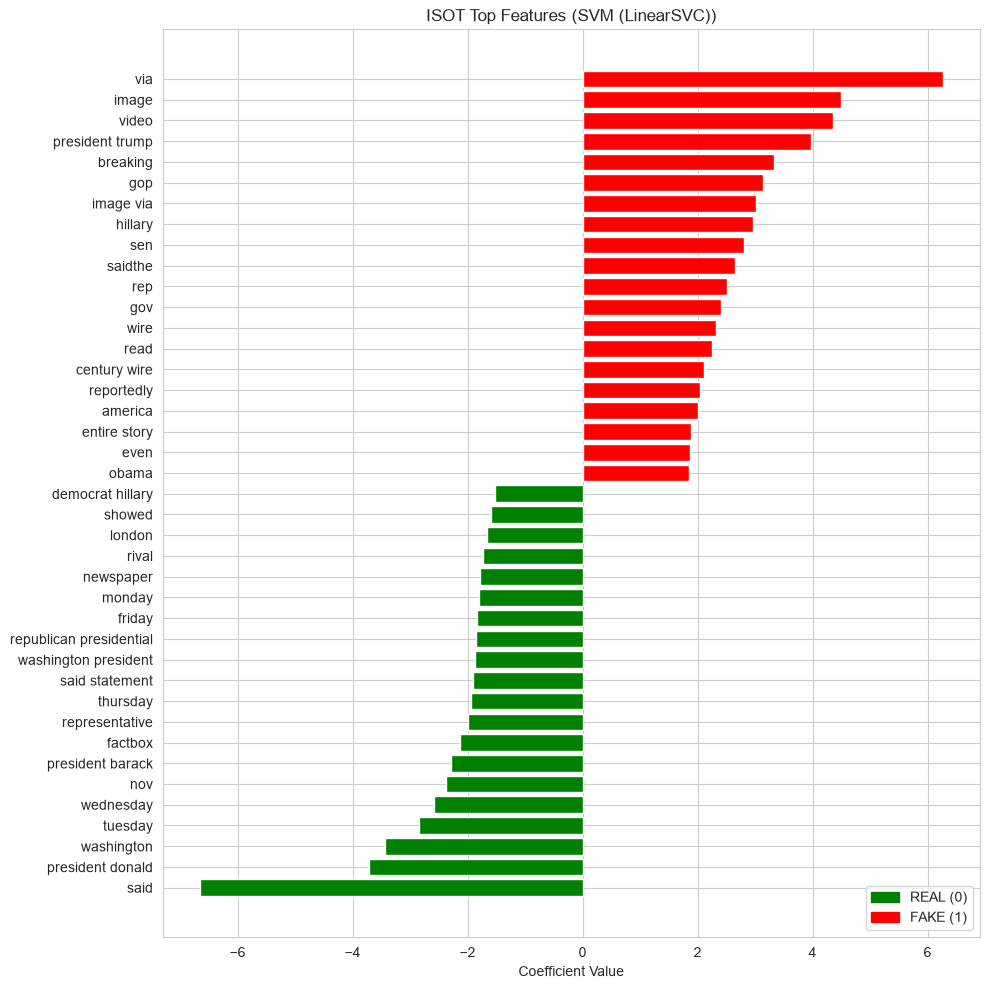

In [12]:
# 1.1 ISOT Best Model
isot_report = json.load(open(ROOT / 'reports' / '08_comparison' / 'comparison_summary.json'))
isot_best_name = isot_report['best_model']
isot_filename = get_model_filename(isot_best_name, is_welfake=False)

print(f"Loading ISOT Best Model: {isot_best_name}...")
isot_model = joblib.load(MODELS_DIR / isot_filename)
isot_vec = joblib.load(MODELS_DIR / 'tfidf_vectorizer.pkl')
isot_feature_names = isot_vec.get_feature_names_out()

plot_top_features(isot_model, isot_feature_names, title=f"ISOT Top Features ({isot_best_name})")

Loading WELFake Best Model: Random Forest...


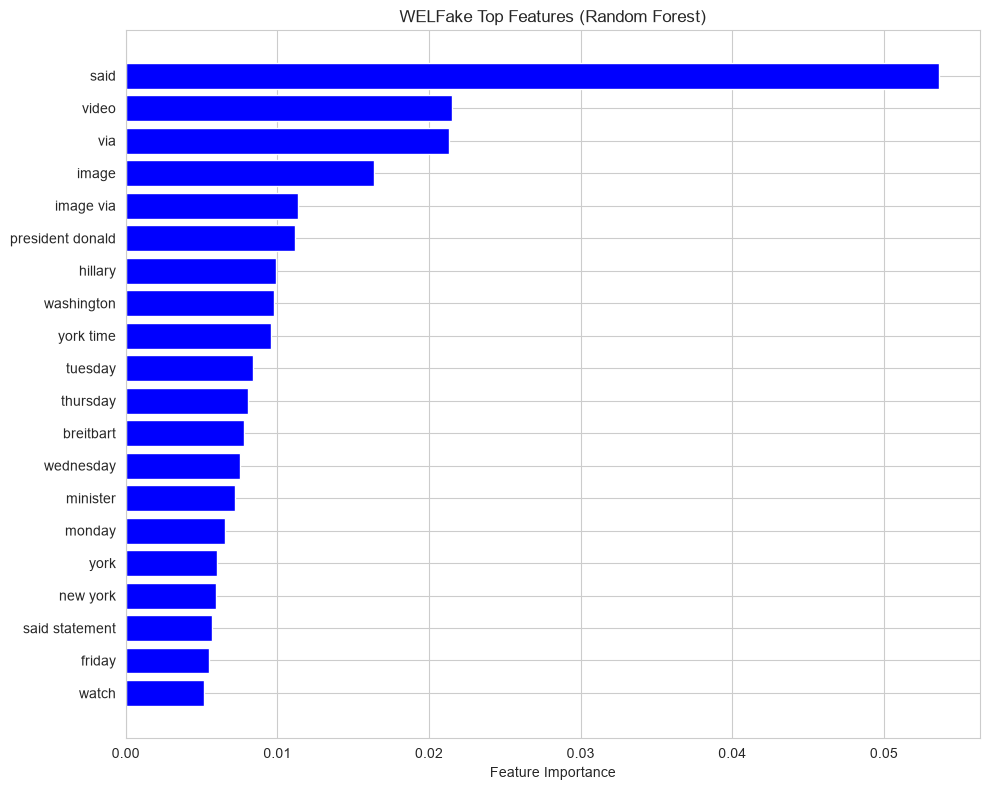

In [13]:
# 1.2 WELFake Best Model
welfake_report = json.load(open(ROOT / 'reports' / '08_1_welfake_comparison' / 'comparison_summary.json'))
welfake_best_name = welfake_report['best_model']
welfake_filename = get_model_filename(welfake_best_name, is_welfake=True)

print(f"Loading WELFake Best Model: {welfake_best_name}...")
welfake_model = joblib.load(MODELS_DIR / welfake_filename)
welfake_vec = joblib.load(MODELS_DIR / 'tfidf_vectorizer_welfake.pkl')
welfake_feature_names = welfake_vec.get_feature_names_out()

plot_top_features(welfake_model, welfake_feature_names, title=f"WELFake Top Features ({welfake_best_name})")

## 2. Error Analysis: Phân tích nguyên nhân lỗi

In [14]:
def analyze_errors(X_test_tfidf, y_test, model, feature_names, dataset_name, X_test_raw=None):
    print(f"\n--- {dataset_name.upper()} ERROR ANALYSIS ---")
    predictions = model.predict(X_test_tfidf)
    
    # Random Forest không có decision_function, ta dùng predict_proba thay thế để lấy độ tự tin
    if hasattr(model, 'decision_function'):
        confidence_scores = model.decision_function(X_test_tfidf)
    else:
        confidence_scores = model.predict_proba(X_test_tfidf)[:, 1] # Xác suất thuộc lớp 1 (FAKE)
    
    fp_indices = np.where((y_test == 0) & (predictions == 1))[0]
    fn_indices = np.where((y_test == 1) & (predictions == 0))[0]
    
    print(f"Total False Positives: {len(fp_indices)}")
    print(f"Total False Negatives: {len(fn_indices)}")
    print("\n")
    
    def print_examples(indices, title, true_label, pred_label):
        print(f">> VÍ DỤ {title} (Thực tế {true_label}, dự đoán {pred_label})")
        if len(indices) == 0:
            print("Không có ví dụ nào.")
            return
            
        # Sắp xếp theo mức độ tự tin sai lầm lớn nhất
        if pred_label == 'FAKE (1)':
            sorted_idx = indices[np.argsort(confidence_scores[indices])[::-1]][:3]
        else:
            sorted_idx = indices[np.argsort(confidence_scores[indices])][:3]
            
        for idx in sorted_idx:
            print(f"\nIndex: {idx} | True: {true_label} | Pred: {pred_label} | Confidence/Decision Score: {confidence_scores[idx]:.4f}")
            if X_test_raw is not None:
                raw_text = X_test_raw.iloc[idx]
                snippet = raw_text[:500] + '...' if len(raw_text) > 500 else raw_text
                print(f"\nTRÍCH ĐOẠN VĂN BẢN GỐC:\n{snippet}\n")
                
            print("Các từ nổi bật (TF-IDF cao) khiến mô hình nhầm lẫn:")
            row_tfidf = X_test_tfidf[idx].toarray()[0]
            top_words_idx = np.argsort(row_tfidf)[::-1]
            
            count = 0
            for w_idx in top_words_idx:
                if row_tfidf[w_idx] > 0:
                    word = feature_names[w_idx]
                    
                    if hasattr(model, 'coef_'):
                        weight = model.coef_[0][w_idx]
                        if pred_label == 'FAKE (1)' and weight > 0:
                            print(f" - {word!r}: TF-IDF = {row_tfidf[w_idx]:.3f} (Model weight: {weight:.3f} -> pushes to FAKE)")
                            count += 1
                        elif pred_label == 'REAL (0)' and weight < 0:
                            print(f" - {word!r}: TF-IDF = {row_tfidf[w_idx]:.3f} (Model weight: {weight:.3f} -> pushes to REAL)")
                            count += 1
                    elif hasattr(model, 'feature_importances_'):
                        importance = model.feature_importances_[w_idx]
                        if importance > 0.0001:
                            print(f" - {word!r}: TF-IDF = {row_tfidf[w_idx]:.3f} (Model Importance: {importance:.4f} -> Highly Important)")
                            count += 1
                        
                if count >= 10:
                    break
            print("-" * 50)
            
    print_examples(fp_indices, "FALSE POSITIVES", "REAL (0)", "FAKE (1)")
    print_examples(fn_indices, "FALSE NEGATIVES", "FAKE (1)", "REAL (0)")

In [15]:
# 2.1 ISOT Error Analysis
print("Loading ISOT Test Data...")
X_test_isot = joblib.load(ROOT / 'data' / 'X_test_tfidf.pkl')
y_test_isot = joblib.load(ROOT / 'data' / 'y_test.pkl')
X_test_isot_raw = joblib.load(ROOT / 'data' / 'X_test.pkl')
analyze_errors(X_test_isot, y_test_isot, isot_model, isot_feature_names, "ISOT", X_test_isot_raw)

Loading ISOT Test Data...

--- ISOT ERROR ANALYSIS ---
Total False Positives: 29
Total False Negatives: 49


>> VÍ DỤ FALSE POSITIVES (Thực tế REAL (0), dự đoán FAKE (1))

Index: 586 | True: REAL (0) | Pred: FAKE (1) | Confidence/Decision Score: 2.4998

TRÍCH ĐOẠN VĂN BẢN GỐC:
Senators reach deal to help state water programs after Flint WASHINGTON (Reuters) - U.S. Senators unveiled legislation on Wednesday providing federal aid to help states fix water infrastructure in the wake of Flint, Michigan’s crisis over lead-tainted drinking water.  Senators James Inhofe, an Oklahoma Republican, and Debbie Stabenow, a Michigan Democrat, and others introduced the measure providing $100 million to a revolving fund states can tap if they have drinking water problems. The funding ...

Các từ nổi bật (TF-IDF cao) khiến mô hình nhầm lẫn:
 - 'america': TF-IDF = 0.228 (Model weight: 2.010 -> pushes to FAKE)
 - 'trump': TF-IDF = 0.217 (Model weight: 0.150 -> pushes to FAKE)
 - 'phony': TF-IDF = 0.118 (M

In [16]:
# 2.2 WELFake Error Analysis
print("Loading WELFake Test Data...")
X_test_welfake = joblib.load(ROOT / 'data' / 'welfake' / 'X_test_tfidf.pkl')
y_test_welfake = joblib.load(ROOT / 'data' / 'welfake' / 'y_test.pkl')
X_test_welfake_raw = joblib.load(ROOT / 'data' / 'welfake' / 'X_test.pkl')
analyze_errors(X_test_welfake, y_test_welfake, welfake_model, welfake_feature_names, "WELFake", X_test_welfake_raw)

Loading WELFake Test Data...

--- WELFAKE ERROR ANALYSIS ---
Total False Positives: 250
Total False Negatives: 292


>> VÍ DỤ FALSE POSITIVES (Thực tế REAL (0), dự đoán FAKE (1))

Index: 10165 | True: REAL (0) | Pred: FAKE (1) | Confidence/Decision Score: 0.8600

TRÍCH ĐOẠN VĂN BẢN GỐC:
Putting Presidential Polls in Perspective Both Donald Trump and Hillary Clinton have struggled to win over a majority of voters, but so far the Democratic nominee has shown greater potential to grow her support

Các từ nổi bật (TF-IDF cao) khiến mô hình nhầm lẫn:
 - 'putting': TF-IDF = 0.246 (Model Importance: 0.0001 -> Highly Important)
 - 'potential': TF-IDF = 0.212 (Model Importance: 0.0002 -> Highly Important)
 - 'poll': TF-IDF = 0.208 (Model Importance: 0.0003 -> Highly Important)
 - 'nominee': TF-IDF = 0.201 (Model Importance: 0.0003 -> Highly Important)
 - 'majority': TF-IDF = 0.201 (Model Importance: 0.0003 -> Highly Important)
 - 'voter': TF-IDF = 0.187 (Model Importance: 0.0003 -> Highly Impor